<a href="https://colab.research.google.com/github/piyakorn-h/Super-AI-Engineer-Season-6/blob/main/House_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# สมมติไฟล์ชื่อ house_data.zip อยู่ในโฟลเดอร์ชื่อ MyProject ใน Drive
!cp /content/drive/MyDrive/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip /content/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import zipfile

# 1. แตกไฟล์ Zip
zip_path = '/content/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip'
extract_path = '/content/house_recognition'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ แตกไฟล์เรียบร้อย!")

# 2. สำรวจไฟล์ข้างใน
print("\n📁 รายชื่อไฟล์/โฟลเดอร์หลัก:")
!ls -F {extract_path}

✅ แตกไฟล์เรียบร้อย!

📁 รายชื่อไฟล์/โฟลเดอร์หลัก:
sample_submission.csv  test/  train/  train.csv


In [ ]:
import pandas as pd
import os
import glob

# --- 1. ตั้ง Path ใหม่ตามรูปที่เห็น ---
train_csv_path = '/content/house_recognition/train.csv'
# ดูจากรูป โฟลเดอร์รูปจริงๆ น่าจะอยู่ที่นี่
img_dir = '/content/house_recognition/train/train'

df_main = pd.read_csv(train_csv_path)

# กวาดชื่อไฟล์รูปทั้งหมดในโฟลเดอร์มาก่อน
all_files = os.listdir(img_dir)
print(f"📊 พบไฟล์ทั้งหมดในโฟลเดอร์: {len(all_files)} ไฟล์")

train_data = []

# 2. วนลูปเช็กรายชื่อจาก CSV
for idx, row in df_main.iterrows():
    id_name = str(row[0]).strip() # เช่น 'ChokChai4'
    label = row[1]

    # ค้นหาไฟล์ที่มีชื่อ id_name อยู่ข้างใน
    # เช่น ถ้า id คือ 'ChokChai4' มันจะเก็บทุกลูกที่ชื่อมีคำว่า 'ChokChai4'
    matches = [f for f in all_files if id_name in f and f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    for f_name in matches:
        train_data.append({
            'img_path': os.path.join(img_dir, f_name),
            'label': label,
            'folder_id': id_name # หรือเปลี่ยนเป็น 'id' ตามคอลัมน์ใน CSV
        })

df_train_expanded = pd.DataFrame(train_data)

print("\n" + "="*30)
print(f"✅ จับคู่สำเร็จ!")
print(f"🏠 จำนวน ID ใน CSV: {len(df_main)}")
print(f"🖼️ จำนวนรูปภาพที่ Match เจอ: {len(df_train_expanded)}")
print("="*30)

if len(df_train_expanded) > 0:
    display(df_train_expanded.head())
else:
    # ถ้ายังไม่เจอ ให้ลองปริ้นชื่อไฟล์มาดู 5 อัน
    print("❌ ยังไม่เจอ! นี่คือตัวอย่างชื่อไฟล์ในโฟลเดอร์:")
    print(all_files[:5])

📊 พบไฟล์ทั้งหมดในโฟลเดอร์: 2954 ไฟล์


/tmp/ipykernel_31979/3092252695.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  id_name = str(row[0]).strip() # เช่น 'ChokChai4'
/tmp/ipykernel_31979/3092252695.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label = row[1]



✅ จับคู่สำเร็จ!
🏠 จำนวน ID ใน CSV: 2953
🖼️ จำนวนรูปภาพที่ Match เจอ: 2953


,img_path,label,folder_id
0,/content/house_recognition/train/train/ChokCha...,0,ChokChai4_img_13-7956791_100-6031267_a187-2159...
1,/content/house_recognition/train/train/ChokCha...,0,ChokChai4_img_13-7961753_100-6031881_a185-9785...
2,/content/house_recognition/train/train/ChokCha...,0,ChokChai4_img_13-7969811_100-5906061_a180-5812...
3,/content/house_recognition/train/train/ChokCha...,0,ChokChai4_img_13-7970811_100-5906071_a180-5812...
4,/content/house_recognition/train/train/ChokCha...,0,ChokChai4_img_13-7971811_100-5906081_a180-5812...


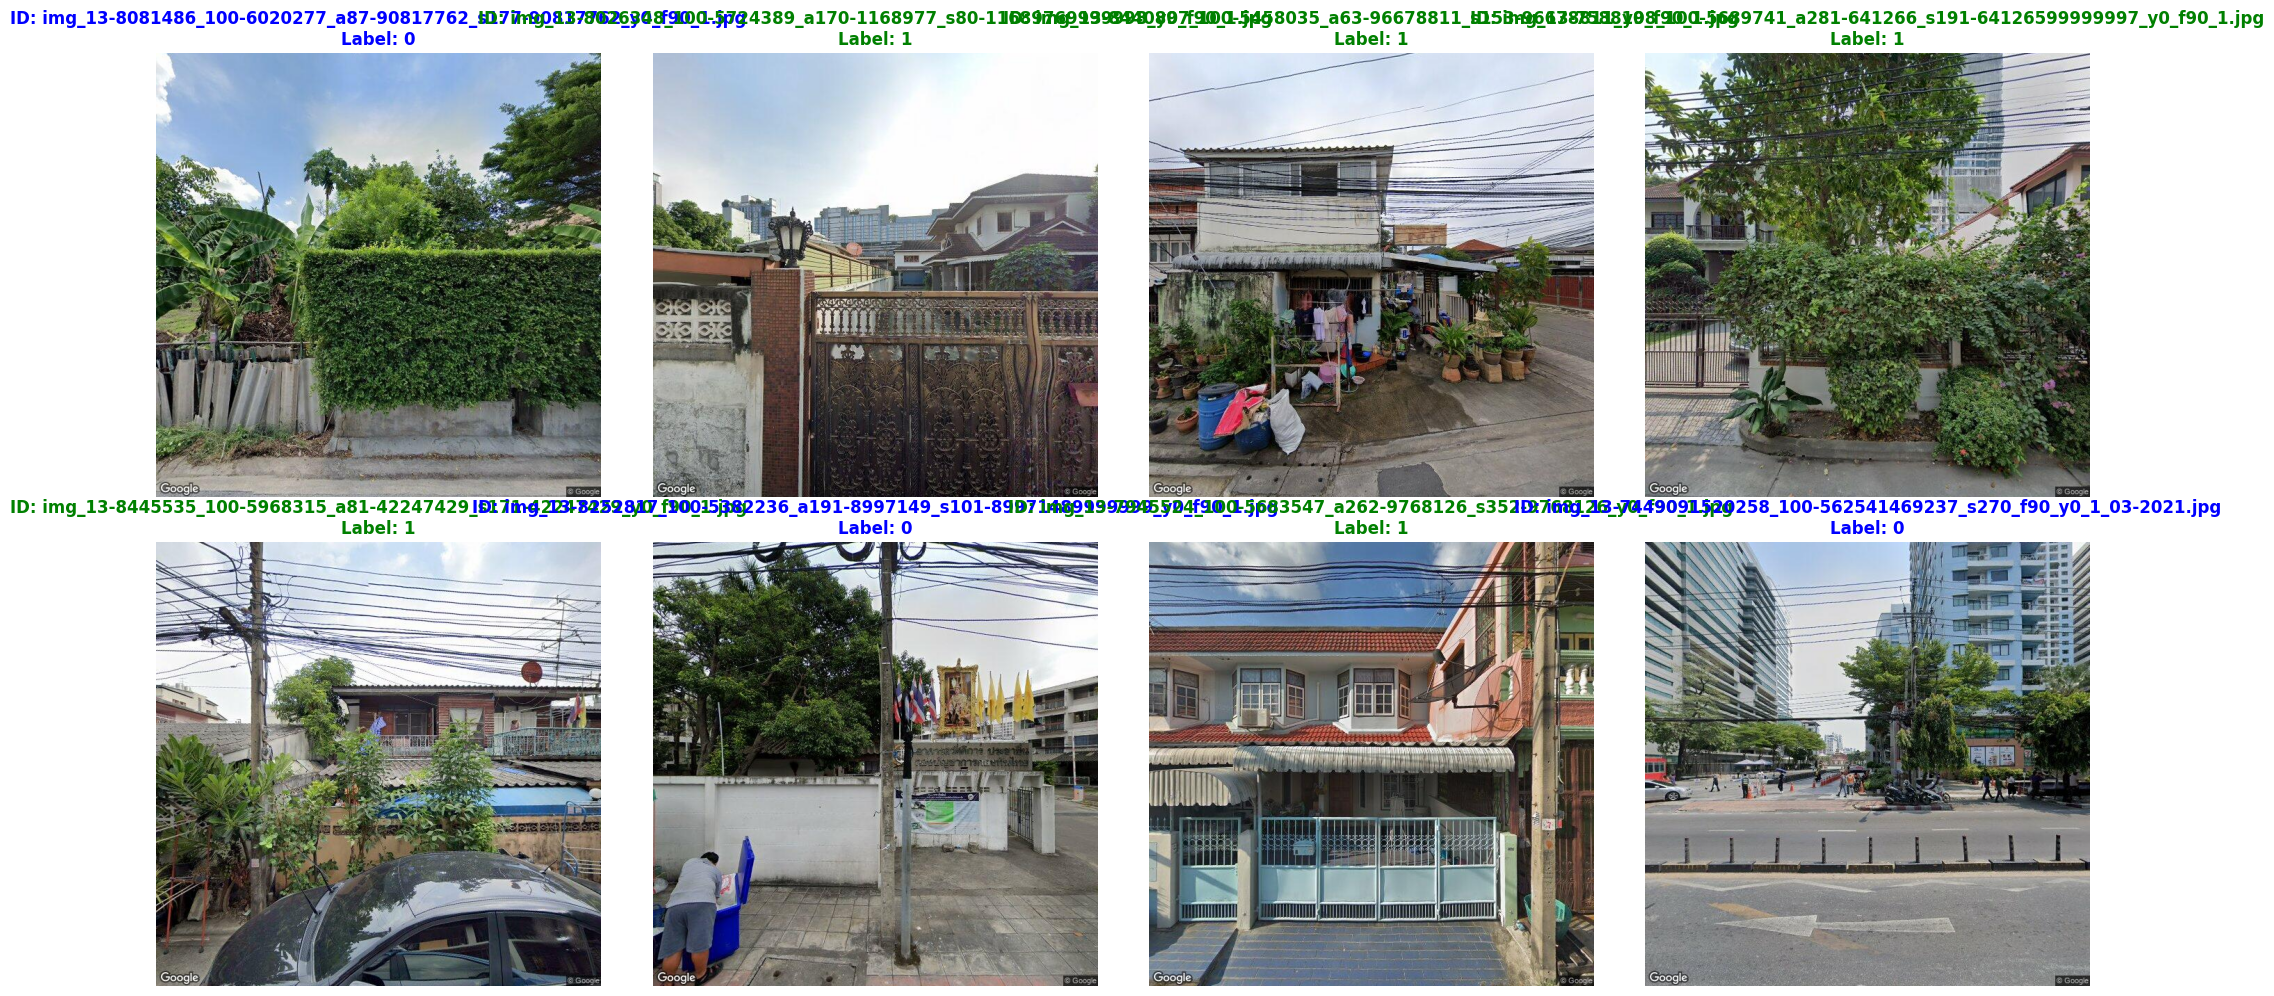

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

# 1. สุ่มดึงข้อมูลมา 8 ตัวอย่างจากตารางที่เรา Match เจอ
samples = df_train_expanded.sample(min(8, len(df_train_expanded))).to_dict('records')

plt.figure(figsize=(20, 10))

for i, sample in enumerate(samples):
    img_path = sample['img_path']
    label = sample['label']
    folder_id = sample['folder_id']

    # อ่านรูปด้วย OpenCV
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # แปลงสี BGR เป็น RGB

        plt.subplot(2, 4, i+1)
        plt.imshow(img)
        # แสดง ID และ Label (0 หรือ 1)
        color = 'green' if label == 1 else 'blue'
        plt.title(f"ID: {folder_id}\nLabel: {label}", color=color, fontsize=12, fontweight='bold')
        plt.axis('off')
    else:
        print(f"⚠️ ไม่สามารถอ่านรูปได้: {img_path}")

plt.tight_layout()
plt.show()

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    # 1. หัวใจหลัก: สุ่มตัดและขยาย (เลียนแบบการซูมเข้าไปที่ตัวบ้าน)
    # scale=(0.7, 1.0) คือสุ่มตัดพื้นที่ 70% ถึง 100% ของรูปเดิม
    # วิธีนี้จะช่วยให้โมเดลหัดมองแค่ 'บางส่วน' ของบ้าน และตัดพื้นหลังออกไปเองในบางรอบ
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0), ratio=(0.75, 1.33)),

    # 2. กลับด้านซ้าย-ขวา (บ้านมองมุมไหนก็ยังเป็นบ้าน)
    transforms.RandomHorizontalFlip(p=0.5),

    # 3. หมุนภาพเล็กน้อย (เผื่อมุมกล้องคนถ่ายเอียง)
    transforms.RandomRotation(15),

    # 4. ปรับแสงและสี (สำคัญมาก! เพราะรูปบ้านแต่ละเวลาแสงไม่เท่ากัน)
    # brightness = ความสว่าง, contrast = ความคมชัด, saturation = ความสดของสี
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    # 5. ใส่ Noise เล็กน้อย (ทางเลือก: ถ้าอยากให้โมเดลทนทานต่อภาพแตก)
    # transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5)),

    # 6. แปลงเป็น Tensor และ Normalize (ใช้ค่ามาตรฐานของ ImageNet)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

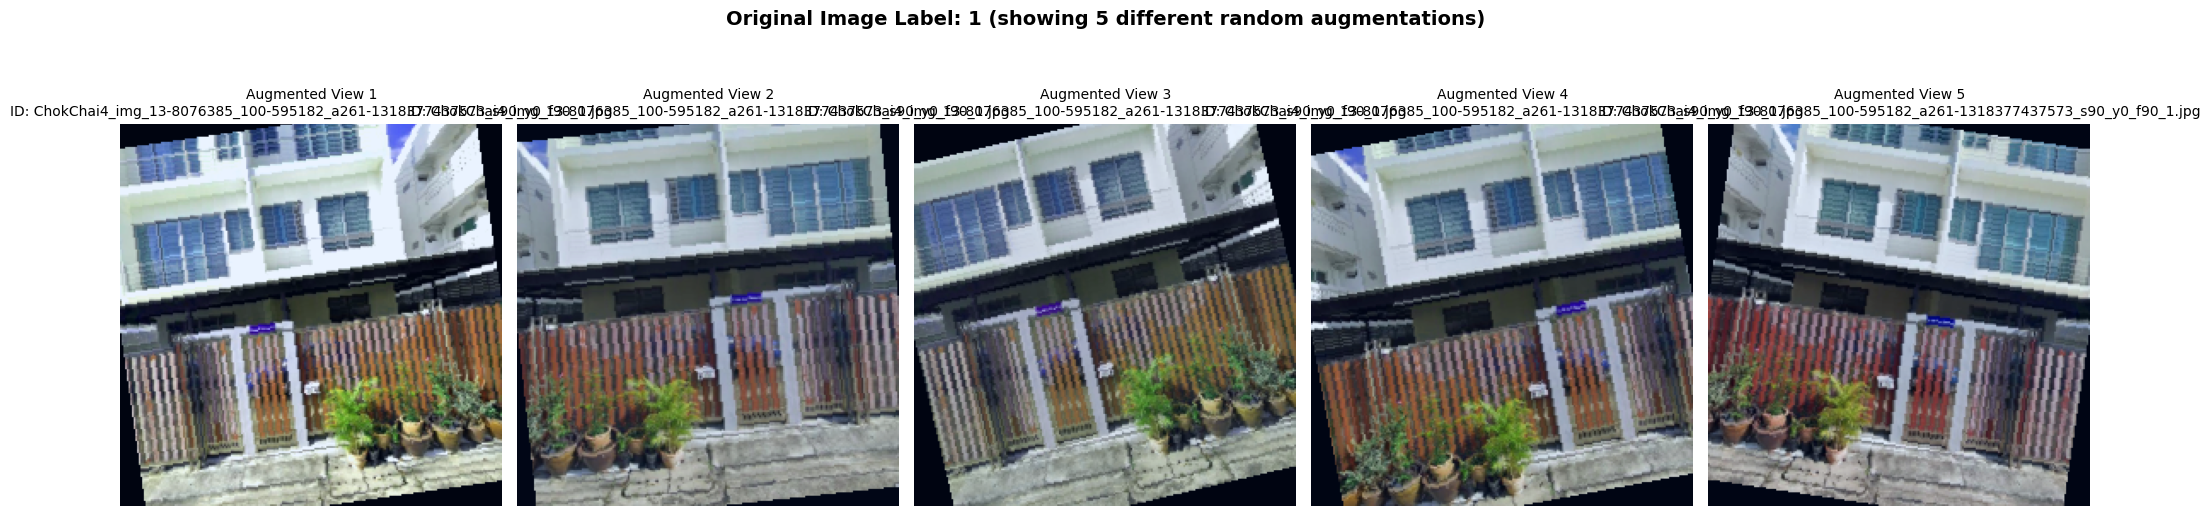

In [ ]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np
import torch

# 1. สุ่มดึงมาแค่ 1 รูปเพื่อดูความหลากหลายของการ Augment
sample = df_train_expanded.sample(1).iloc[0]
img_path = sample['img_path']
label = sample['label']
folder_id = sample['folder_id']

# 2. อ่านรูปต้นฉบับ
img = cv2.imread(img_path)
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)

    plt.figure(figsize=(20, 6))

    # วนลูป 5 รอบ เพื่อดูผลลัพธ์ที่ต่างกันจากการสุ่ม (Randomness)
    for i in range(5):
        # ทุกครั้งที่เรียก train_transform มันจะสุ่ม Crop/หมุน/ปรับสี ใหม่เสมอ
        transformed_img_tensor = train_transform(pil_img)

        # แปลง Tensor กลับเป็น NumPy (H, W, C)
        # Note: เราไม่ Un-normalize เพื่อให้เห็น "สิ่งที่โมเดลเห็น" จริงๆ
        img_display = transformed_img_tensor.permute(1, 2, 0).numpy()

        # ปรับค่าให้อยู่ในสเกล [0, 1] เพื่อให้ plt.imshow แสดงผลได้
        img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

        plt.subplot(1, 5, i+1)
        plt.imshow(img_display)
        plt.title(f"Augmented View {i+1}\nID: {folder_id}", fontsize=10)
        plt.axis('off')

    plt.suptitle(f"Original Image Label: {label} (showing 5 different random augmentations)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ ไม่สามารถอ่านรูปได้: {img_path}")

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import timm
import os
from PIL import Image

# Define the HouseDataset class
class HouseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['img_path']
        label = self.dataframe.iloc[idx]['label']

        # Load image
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

# สร้าง Dataset จากตารางที่เรา Match เจอ (ใช้ Full Data)
full_train_dataset = HouseDataset(df_train_expanded, train_transform)

# สร้าง DataLoader (ปรับ batch_size ตาม RAM GPU ถ้าหลุดให้ลดเหลือ 16)
full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print(f"🔥 เริ่มลุย Full Training ด้วยข้อมูล {len(full_train_dataset)} รูป")

🔥 เริ่มลุย Full Training ด้วยข้อมูล 2953 รูป


In [ ]:
# 1. ตั้งค่า Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. โหลด Model EfficientNet-V2-S
model = timm.create_model('efficientnetv2_rw_s', pretrained=True, num_classes=2)
model = model.to(device)

# 3. Loss & Optimizer
criterion = nn.CrossEntropyLoss() # ใช้ตัวนี้ต้องส่ง Label เป็น Long
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12) # ปรับ LR ให้สมูทขึ้น

# 4. ลูปเทรน (Full Training)
epochs = 12

print(f"🚀 เริ่มเทรนบนเครื่อง: {device}")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(full_train_loader, desc=f'Epoch {epoch+1}/{epochs}')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device).long() # บังคับเป็น Long เพื่อป้องกัน Error

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'Loss': f"{running_loss/(pbar.n+1):.4f}", 'Acc': f"{100.*correct/total:.2f}%"})

    scheduler.step()

    # Save Checkpoint
    if (epoch + 1) % 3 == 0 or (epoch + 1) == epochs:
        torch.save(model.state_dict(), f'house_model_ep{epoch+1}.pth')

print("\n🎉 เทรนเสร็จแล้ว")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


🚀 เริ่มเทรนบนเครื่อง: cpu


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/12:   0%|          | 0/93 [00:00<?, ?it/s]

KeyboardInterrupt: 